In [10]:
import scanpy as sc
import pandas as pd

from itertools import combinations

from tqdm import tqdm
import random

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed


In [2]:
panel = pd.read_csv('/Users/mathieu/Library/CloudStorage/GoogleDrive-mbourdenx@me.com/My Drive/UCL/Projects/MERSCOPEvsXENIUM/Panel/panel.csv')

In [3]:
panel.index = panel.Gene

In [4]:
adata = sc.read_h5ad('../../Reference_MTG_RNAseq_final-nuclei.2022-06-07.h5ad')

In [5]:
missing = list()

for i in panel.Gene:
    if i not in adata.var.index:
        print(i)
        missing.append(i)

NDP52
ALIX
H2AX


In [6]:
# Remove missing genes
panel = panel.drop(index=missing)

In [7]:
pairs = list(combinations(panel.Gene, 2))
len(pairs)

43956

In [ ]:
# Random sampling of all possible pairs
mecr = {}

for i in raandom.sample(pairs, 1000):

    gene1, gene2 = i[0], i[1]
    n_both = (adata[:, gene1].X.todense() > 0) & (adata[:, gene2].X.todense() > 0)
    n_one = (adata[:, gene1].X.todense() > 0) | (adata[:, gene2].X.todense() > 0)

    mecr[i] = n_both.sum() / n_one.sum()

In [13]:
def compute_mecr(pair, adata):

    gene1, gene2 = pair[0], pair[1]
    n_both = (adata[:, gene1].X.todense() > 0) & (adata[:, gene2].X.todense() > 0)
    n_one = (adata[:, gene1].X.todense() > 0) | (adata[:, gene2].X.todense() > 0)

    return [pair, n_both.sum() / n_one.sum()]


In [ ]:
# Parallel processing of all possible combinations
mecr = Parallel(n_jobs=20, verbose=1)(delayed(compute_mecr)(pair, adata) for pair in pairs)

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    7.8s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:   26.6s
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:   58.0s
[Parallel(n_jobs=20)]: Done 760 tasks      | elapsed:  1.8min
[Parallel(n_jobs=20)]: Done 1210 tasks      | elapsed:  2.8min
[Parallel(n_jobs=20)]: Done 1760 tasks      | elapsed:  4.0min
[Parallel(n_jobs=20)]: Done 2410 tasks      | elapsed:  5.4min
[Parallel(n_jobs=20)]: Done 3160 tasks      | elapsed:  7.0min
[Parallel(n_jobs=20)]: Done 4010 tasks      | elapsed:  8.8min
[Parallel(n_jobs=20)]: Done 4960 tasks      | elapsed: 10.8min
[Parallel(n_jobs=20)]: D

In [15]:
mecr_dict = dict()

for i in mecr:
    mecr_dict[i[0]] = i[1]

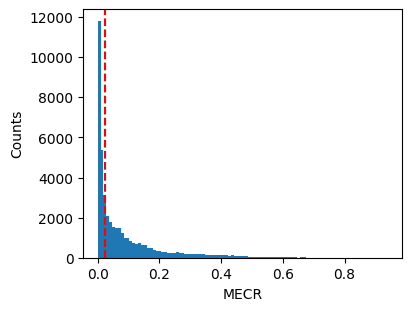

In [20]:
plt.figure(figsize=(4,3), constrained_layout=True)
plt.hist(mecr_dict.values(), bins=100)
plt.axvline(x=0.025, c='r', linestyle='dashed')
plt.ylabel('Counts')
plt.xlabel('MECR')
plt.savefig('../Figures/mecr_snrnaseq.png', dpi=300)
plt.show()

In [22]:
selected_pairs = []

for i,j in zip(mecr_dict.keys(), mecr_dict.values()):
    if j < 0.025:
        selected_pairs.append(i)
    

In [23]:
len(selected_pairs)

19363

In [24]:
np.save(file='../../selected_pairs.npy', arr=selected_pairs)